In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn jupyter

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Basic Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# To hide warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Loading the dataset
california_data = fetch_california_housing(as_frame=True)

# Combining Features (data) and Target (price) into a single dataframe
df = pd.concat([california_data.data, california_data.target.rename('MedHouseVal')], axis=1)

# Viewing the first 5 rows to check the data
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


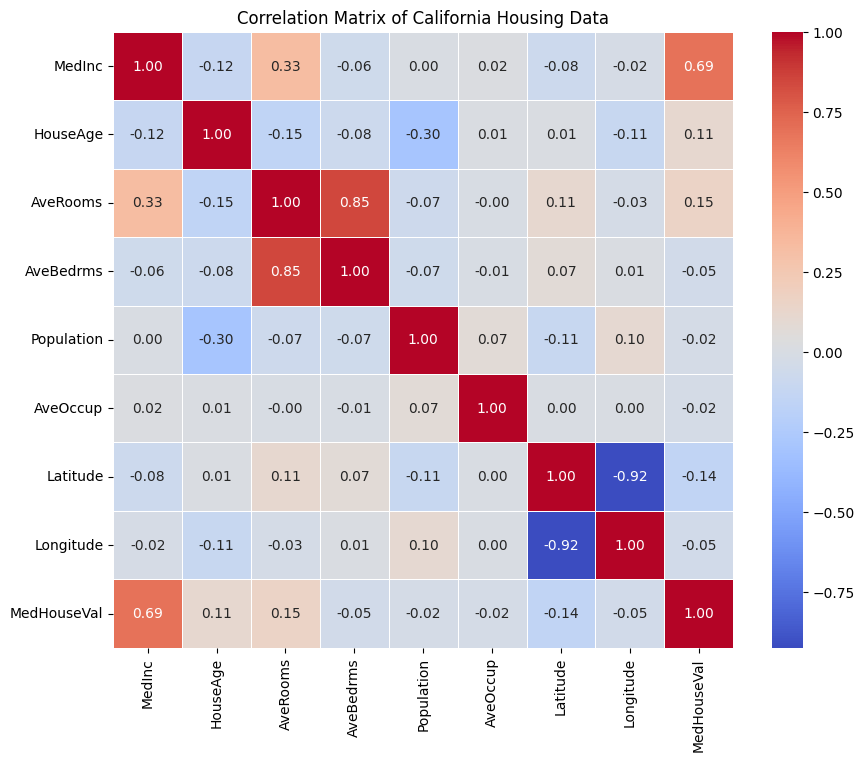

In [4]:
# 1. Checking for missing values (This dataset has no missing values, but it's good practice to check)
print("Missing Values:\n", df.isnull().sum())

# 2. Viewing basic data statistics
display(df.describe())

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of California Housing Data")
plt.show()

In [5]:
# X = Features (Input variables)
X = df.drop(columns='MedHouseVal')

# y = Target
y = df['MedHouseVal']

# Splitting the data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

Training Data Size: (16512, 8)
Testing Data Size: (4128, 8)


In [6]:
# Initializing the model
model = LinearRegression()

# Training the model on the Training data
model.fit(X_train, y_train)

# After training, making predictions on the Testing data
y_pred = model.predict(X_test)

print("Model training complete and predictions generated!")

Model training complete and predictions generated!


In [7]:
# Calculating errors
mae = mean_absolute_error(y_test, y_pred)

# Note: 'squared=False' has been removed in newer versions of scikit-learn, so using np.sqrt() is safer
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2) Score: {r2:.3f}")

Mean Absolute Error (MAE): 0.533
Root Mean Squared Error (RMSE): 0.746
R-squared (R2) Score: 0.576


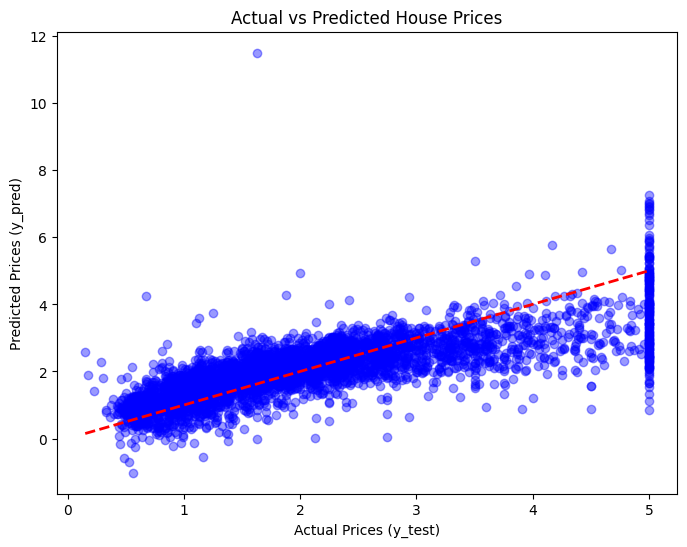

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')

# Ek perfect prediction line draw karna (Red line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

plt.xlabel("Actual Prices (y_test)")
plt.ylabel("Predicted Prices (y_pred)")
plt.title("Actual vs Predicted House Prices")
plt.show()

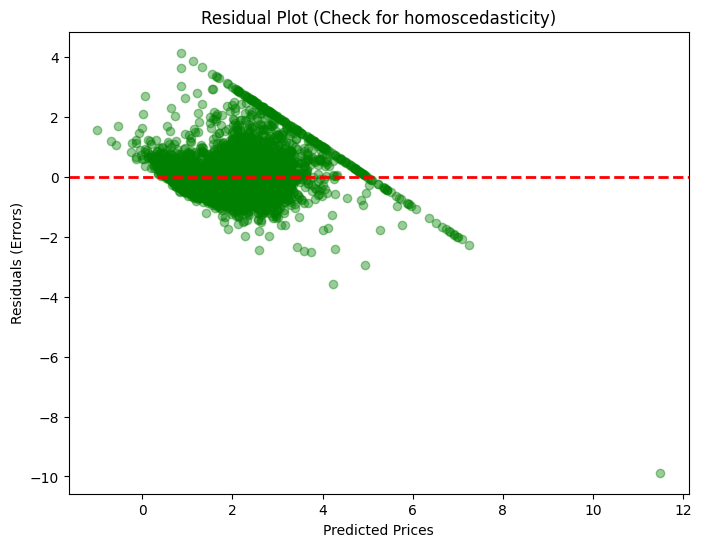

In [9]:
# Residuals = Actual value - Predicted value
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4, color='green')

# Zero error line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot (Check for homoscedasticity)")
plt.show()